# 49 — LSEG/Gemma strict story-revision sign flips

**Question.** Does the economically sharp subset of Reuters revisions whose
Gemma tone crosses zero produce a sparse, cost-surviving strategy?

**Why this is distinct.** Notebook 47 found that first-to-current revision
direction beats a matched latest-level construction before costs, but its
broad one-session strategy breaks even at only 4.49 bps/side. This notebook
freezes one return-blind semantic restriction: the first and current scores
must have strictly opposite signs. Zero-valued endpoints abstain. There is no
magnitude threshold, parameter sweep, duration choice, or return-selected
variant.

**Frozen before returns.** Use the immutable original 33 companies. For each
family revision, require `initial_score × current_score < 0`, retain only
companies associated with both endpoints, map the current revision to the
first open at least 15 minutes later, and keep the latest transition per
family/company/open. Average current scores within firm-open. Long current-
positive flips and short current-negative flips for one open-to-open interval,
with equal legs, a 25% single-name cap, unused capacity in cash, and 10 bps per
traded side. Notebook 47's broad revision-delta arm is the sole strategy
comparator and must reproduce exactly.

The return-free gate requires at least 300 sign-flip transition associations,
300 nonzero firm-opens, 25 companies, 60 both-sign sessions, at least 20 in
each chronological half, and exact compliance with the 25% cap. Net sign-flip
return versus cash and versus the broad revision arm form one two-test BH
family. A conditional random-name test preserves each active date, long/short
count, feasible gross, and same-day revision-update universe. Factor, temporal,
and leave-one-out checks remain binding. The LSEG return window is already
open, so even a pass is a retrospective candidate, not validated alpha.

In [1]:
from __future__ import annotations

import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import Markdown, display
from statsmodels.stats.multitest import multipletests

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.lseg_expanded import (  # noqa: E402
    load_price_exports,
    load_success_scores,
)
from final_experiments.lib.lseg_story_families import (  # noqa: E402
    load_family_revision_transitions,
)
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import (  # noqa: E402
    paired_block_bootstrap_difference,
)
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from final_experiments.lib.sparse_spread import (  # noqa: E402
    build_exact_extrema_targets,
    ledger_rows_to_frame,
)
from sentiment_benchmark.artifact_io import sha256_file  # noqa: E402
from sentiment_benchmark.strategy_research.ledger import (  # noqa: E402
    run_open_to_open_ledger,
)
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402
from sentiment_benchmark.strategy_research.portfolio import (  # noqa: E402
    TargetPortfolio,
)

SEED = 20260818
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 5
REPLICATIONS = 9_999
SINGLE_NAME_CAP = 0.25
INITIAL_NAV = 1_000_000.0
MIN_FLIP_TRANSITION_ASSOCIATIONS = 300
MIN_FIRM_OPENS = 300
MIN_SYMBOLS = 25
MIN_ACTIVE_SESSIONS = 60
MIN_HALF_ACTIVE_SESSIONS = 20

COLLECTION_DIR = REPO_ROOT / "Data/collections/lseg_us_sector_44_8m_headlines/derived"
GEMMA_PATH = (
    COLLECTION_DIR
    / "headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv"
)
MERGED_HEADLINES = COLLECTION_DIR / "merged/headlines.jsonl"
AGGREGATE_PANEL = (
    REPO_ROOT
    / "final_experiments/outputs/13_lseg_44_gemma_robustness"
    / "gemma4_26b_firm_open_aggregators.parquet"
)
NOTEBOOK47_MANIFEST = (
    REPO_ROOT
    / "final_experiments/outputs/47_lseg_gemma_story_revision_delta/manifest.json"
)
PRICE_PATHS = (
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv",
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_add11_8m.csv",
)
OUTPUT_DIR = (
    REPO_ROOT / "final_experiments/outputs/49_lseg_gemma_story_revision_sign_flip"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SECTOR_MEMBERS_33 = {
    sector: tuple(members[:3]) for sector, members in SECTOR_MEMBERS.items()
}
ORIGINAL_SYMBOLS = tuple(
    sorted(symbol for members in SECTOR_MEMBERS_33.values() for symbol in members)
)
SECTOR_BY_SYMBOL = {
    symbol: sector
    for sector, members in SECTOR_MEMBERS_33.items()
    for symbol in members
}

apply_house_style()
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Licence-safe family transitions and score changes

No price or return value is loaded in this section. The family helper reads
local licensed text only to recreate the existing normalized hash. It returns
hashes, timestamps, revision numbers, and shared company symbols—never text or
raw vendor story identifiers. Only aggregate counts are displayed.

In [2]:
notebook47 = json.loads(NOTEBOOK47_MANIFEST.read_text(encoding="utf-8"))
if notebook47.get("status") != "RETROSPECTIVE_REVISION_DELTA_NO_GO":
    raise ValueError("Notebook 47 revision contract is not the frozen completed run")

gemma_scores, score_audit = load_success_scores(GEMMA_PATH, scorer="gemma4_26b")
transitions, family_audit = load_family_revision_transitions(
    MERGED_HEADLINES,
    expected_hashes=set(gemma_scores["headline_sha256"]),
)
score_map = gemma_scores.set_index("headline_sha256")["score"]
transitions["initial_score"] = transitions["initial_headline_sha256"].map(score_map)
transitions["current_score"] = transitions["current_headline_sha256"].map(score_map)
if transitions[["initial_score", "current_score"]].isna().any().any():
    raise RuntimeError("family transition score join is incomplete")
transitions["score_delta"] = transitions["current_score"] - transitions["initial_score"]
transitions = transitions.loc[
    transitions["headline_changed"] & transitions["shared_symbols"].ne("")
].copy()
eligible_transition_rows = len(transitions)
transitions["strict_sign_flip"] = (
    transitions["initial_score"] * transitions["current_score"]
).lt(0.0)

transition_summary = pd.DataFrame(
    [
        {
            "successful_gemma_hashes": score_audit["unique_successes"],
            "story_families": family_audit["story_families_in_score_population"],
            "multirow_families": family_audit["families_with_multiple_rows"],
            "all_later_revision_rows": family_audit["transition_rows"],
            "changed_headline_shared_symbol_transitions": eligible_transition_rows,
            "strict_sign_flip_transition_rows": int(
                transitions["strict_sign_flip"].sum()
            ),
            "strict_definition": "initial_score * current_score < 0",
            "licensed_headline_text_emitted": False,
            "raw_story_ids_emitted": False,
        }
    ]
)
display(transition_summary.T)

,0
successful_gemma_hashes,888155
story_families,1149954
multirow_families,3638
all_later_revision_rows,8742
changed_headline_shared_symbol_transitions,8654
strict_sign_flip_transition_rows,1508
strict_definition,initial_score * current_score < 0
licensed_headline_text_emitted,False
raw_story_ids_emitted,False


## Strictly pre-open firm-open revision signal

Only `symbol` and `session_date` are read from the price exports here. The
transition timestamp plus the frozen 15-minute buffer determines the entry
open. Multiple revisions from one family mapping to the same company/open are
collapsed to the latest available state before averaging across families.

In [3]:
calendar = pd.concat(
    [pd.read_csv(path, usecols=["symbol", "session_date"]) for path in PRICE_PATHS],
    ignore_index=True,
)
calendar["symbol"] = calendar["symbol"].astype(str)
calendar["session_date"] = pd.to_datetime(calendar["session_date"]).dt.normalize()
if calendar.duplicated(["symbol", "session_date"]).any():
    raise ValueError("price calendar has duplicate company-session rows")

calendar_sessions = pd.DatetimeIndex(
    sorted(calendar["session_date"].unique())
).as_unit("ns")
open_utc = (
    calendar_sessions.tz_localize("America/New_York") + np.timedelta64(570, "m")
).tz_convert("UTC")
cutoffs = pd.DatetimeIndex(pd.to_datetime(transitions["revision_timestamp"], utc=True))
cutoffs = cutoffs + np.timedelta64(15, "m")
positions = open_utc.searchsorted(cutoffs, side="left")
valid = positions < len(calendar_sessions)
transitions = transitions.loc[valid].copy()
transitions["entry_session"] = calendar_sessions.take(positions[valid]).to_numpy()
transitions["symbol"] = transitions["shared_symbols"].str.split("|")
transitions = transitions.explode("symbol", ignore_index=True)
transitions["symbol"] = transitions["symbol"].astype(str)
transitions = transitions.loc[transitions["symbol"].isin(ORIGINAL_SYMBOLS)].copy()
transitions = transitions.sort_values(
    [
        "story_family_sha256",
        "symbol",
        "entry_session",
        "revision_timestamp",
        "current_revision_number",
        "current_headline_sha256",
    ],
    kind="mergesort",
).drop_duplicates(
    ["story_family_sha256", "symbol", "entry_session"], keep="last"
)

all_revision_firm_open = (
    transitions.groupby(["entry_session", "symbol"], as_index=False)
    .agg(
        mean_revision_delta=("score_delta", "mean"),
        story_family_updates=("story_family_sha256", "nunique"),
    )
    .rename(columns={"entry_session": "session_date"})
)
all_revision_firm_open = all_revision_firm_open.loc[
    all_revision_firm_open["mean_revision_delta"].abs().gt(1e-12)
].copy()

flip_transitions = transitions.loc[transitions["strict_sign_flip"]].copy()
firm_open = (
    flip_transitions.groupby(["entry_session", "symbol"], as_index=False)
    .agg(
        mean_current_flip_score=("current_score", "mean"),
        sign_flip_families=("story_family_sha256", "nunique"),
    )
    .rename(columns={"entry_session": "session_date"})
)
firm_open["flip_sign"] = np.sign(firm_open["mean_current_flip_score"])
firm_open = firm_open.loc[firm_open["flip_sign"].ne(0.0)].copy()

signal_grid = pd.read_parquet(AGGREGATE_PANEL, columns=["session_date", "symbol"])
signal_grid["session_date"] = pd.to_datetime(signal_grid["session_date"]).dt.normalize()
signal_grid["symbol"] = signal_grid["symbol"].astype(str)
signal_grid = signal_grid.loc[signal_grid["symbol"].isin(ORIGINAL_SYMBOLS)].copy()
if signal_grid.duplicated(["session_date", "symbol"]).any():
    raise ValueError("aggregate scorer grid has duplicate company-session rows")
sessions = pd.DatetimeIndex(sorted(signal_grid["session_date"].unique()))
if len(sessions) != 167 or not signal_grid.groupby("session_date")["symbol"].nunique().eq(33).all():
    raise ValueError("expected the complete immutable 33 by 167 input grid")
firm_open = firm_open.loc[firm_open["session_date"].isin(sessions)].copy()
all_revision_firm_open = all_revision_firm_open.loc[
    all_revision_firm_open["session_date"].isin(sessions)
].copy()
signal_grid = signal_grid.merge(
    all_revision_firm_open,
    on=["session_date", "symbol"],
    how="left",
    validate="one_to_one",
)
signal_grid = signal_grid.merge(
    firm_open,
    on=["session_date", "symbol"],
    how="left",
    validate="one_to_one",
)
signal_grid["revision_sign"] = np.sign(signal_grid["mean_revision_delta"])

## Frozen strict-flip and broad-revision targets

The strict arm trades only sign-crossing families. The Notebook 47 comparator
trades every nonzero mean revision change. Both use the same one-session,
equal-leg, capacity-capped construction; neither is selected on returns.

In [4]:
flip_targets, flip_target_audit = build_exact_extrema_targets(
    signal_grid,
    signal_col="flip_sign",
    single_name_cap=SINGLE_NAME_CAP,
)
delta_targets, delta_target_audit = build_exact_extrema_targets(
    signal_grid,
    signal_col="revision_sign",
    single_name_cap=SINGLE_NAME_CAP,
)

midpoint = sessions[len(sessions) // 2]
active_dates = pd.DatetimeIndex(
    flip_target_audit.loc[flip_target_audit["eligible"], "session_date"]
)
input_summary = pd.DataFrame(
    [
        {
            "eligible_transition_rows": eligible_transition_rows,
            "original33_transition_associations": len(transitions),
            "strict_sign_flip_transition_associations": len(flip_transitions),
            "strict_sign_flip_firm_opens": len(firm_open),
            "strict_sign_flip_symbols": int(firm_open["symbol"].nunique()),
            "flip_sessions": int(firm_open["session_date"].nunique()),
            "both_sign_active_sessions": int(flip_target_audit["eligible"].sum()),
            "first_half_active_sessions": int((active_dates < midpoint).sum()),
            "second_half_active_sessions": int((active_dates >= midpoint).sum()),
            "median_positive_names": float(
                flip_target_audit.loc[
                    flip_target_audit["eligible"], "positive_names"
                ].median()
            ),
            "median_negative_names": float(
                flip_target_audit.loc[
                    flip_target_audit["eligible"], "negative_names"
                ].median()
            ),
            "mean_target_gross_exposure": float(
                flip_target_audit["gross_exposure"].mean()
            ),
            "maximum_name_weight": float(
                flip_target_audit["max_abs_name_weight"].max()
            ),
        }
    ]
)
input_gate = bool(
    len(flip_transitions) >= MIN_FLIP_TRANSITION_ASSOCIATIONS
    and len(firm_open) >= MIN_FIRM_OPENS
    and input_summary.loc[0, "strict_sign_flip_symbols"] >= MIN_SYMBOLS
    and input_summary.loc[0, "both_sign_active_sessions"] >= MIN_ACTIVE_SESSIONS
    and input_summary.loc[0, "first_half_active_sessions"] >= MIN_HALF_ACTIVE_SESSIONS
    and input_summary.loc[0, "second_half_active_sessions"] >= MIN_HALF_ACTIVE_SESSIONS
    and input_summary.loc[0, "maximum_name_weight"] <= SINGLE_NAME_CAP + 1e-12
)
input_summary["return_free_feasibility_gate"] = input_gate
display(input_summary.T)
if not input_gate:
    raise RuntimeError("strict sign-flip strategy stopped at the input gate")

,0
eligible_transition_rows,8654
original33_transition_associations,3819
strict_sign_flip_transition_associations,467
strict_sign_flip_firm_opens,390
strict_sign_flip_symbols,32
flip_sessions,146
both_sign_active_sessions,74
first_half_active_sessions,46
second_half_active_sessions,28
median_positive_names,1.000000


## Open the already-used LSEG return window once

Only after the input gate passes are split-adjusted opens loaded. Recomputed
next-open returns must match Notebook 13's aggregate original-33 return column
to numerical tolerance. Every signal session must have a complete next open.

In [5]:
prices = load_price_exports(*PRICE_PATHS, expected_symbols=44)
prices = prices.loc[prices["symbol"].isin(ORIGINAL_SYMBOLS)].copy()
open_wide = (
    prices.pivot(index="session_date", columns="symbol", values="adjusted_open")
    .sort_index()
    .dropna()
)
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError("signal sessions are not consecutive complete-price sessions")
if locations[-1] + 1 >= len(open_wide):
    raise ValueError("last signal session has no next complete open")

return_rows: list[OpenToOpenReturn] = []
return_matrix_rows: list[np.ndarray] = []
recomputed_rows: list[dict[str, object]] = []
for session, location in zip(sessions, locations, strict=True):
    next_session = open_wide.index[location + 1]
    values = (
        open_wide.loc[next_session, list(ORIGINAL_SYMBOLS)]
        / open_wide.loc[session, list(ORIGINAL_SYMBOLS)]
        - 1.0
    )
    return_matrix_rows.append(values.to_numpy(dtype=float))
    for symbol, value in values.items():
        return_rows.append(
            OpenToOpenReturn(
                symbol=symbol,
                session=str(session.date()),
                next_session=str(next_session.date()),
                value=float(value),
            )
        )
        recomputed_rows.append(
            {
                "session_date": session,
                "symbol": symbol,
                "recomputed_raw_open_h1": float(value),
            }
        )
return_matrix = np.vstack(return_matrix_rows)

stored_returns = pd.read_parquet(
    AGGREGATE_PANEL,
    columns=["session_date", "symbol", "raw_open_h1"],
)
stored_returns["session_date"] = pd.to_datetime(
    stored_returns["session_date"]
).dt.normalize()
stored_returns = stored_returns.loc[
    stored_returns["symbol"].isin(ORIGINAL_SYMBOLS)
].copy()
return_audit = stored_returns.merge(
    pd.DataFrame(recomputed_rows),
    on=["session_date", "symbol"],
    validate="one_to_one",
)
return_audit["absolute_error"] = (
    return_audit["raw_open_h1"] - return_audit["recomputed_raw_open_h1"]
).abs()
if return_audit["absolute_error"].max() > 1e-12:
    raise RuntimeError("price-derived returns do not reproduce Notebook 13")

coverage = pd.DataFrame(
    [
        {
            "sessions": len(sessions),
            "companies": len(ORIGINAL_SYMBOLS),
            "active_sessions": int(flip_target_audit["eligible"].sum()),
            "first_entry_session": sessions.min(),
            "last_entry_session": sessions.max(),
            "last_return_end": open_wide.index[locations[-1] + 1],
            "max_return_reproduction_error": float(
                return_audit["absolute_error"].max()
            ),
            "missing_return_cells": int((~np.isfinite(return_matrix)).sum()),
        }
    ]
)
display(coverage.T)

,0
sessions,167
companies,33
active_sessions,74
first_entry_session,2025-10-27 00:00:00
last_entry_session,2026-06-26 00:00:00
last_return_end,2026-06-29 00:00:00
max_return_reproduction_error,0.000000
missing_return_cells,0


## Drift-aware accounting, costs, and paired inference

The ledger marks weights against after-cost NAV, charges every rebalance, and
folds one forced final liquidation into the last interval. The two primary
comparisons form one BH family; positive estimates favour strict sign flips.

In [6]:
def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected one terminal liquidation after non-empty intervals")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"])
        - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    intervals.loc[last, "end_nav"] = final["end_nav"]
    return intervals


def run_targets(
    targets: tuple[TargetPortfolio, ...],
    returns: list[OpenToOpenReturn],
    *,
    cost_bps: float,
) -> pd.DataFrame:
    full = ledger_rows_to_frame(
        run_open_to_open_ledger(
            targets,
            returns,
            cost_rate_per_side=cost_bps / 10_000.0,
            initial_nav_usd=INITIAL_NAV,
            force_final_liquidation=True,
        )
    )
    return fold_final_liquidation(full)


def summarize_path(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    gross_equity = np.cumprod(1.0 + gross)
    net_equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, net_equity]
    turnover = float(daily["turnover"].sum())
    return {
        "n_sessions": int(len(daily)),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(gross.mean()),
        "mean_net": float(net.mean()),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "ann_vol_net": float(np.std(net, ddof=1) * math.sqrt(252)),
        "total_return_gross": float(gross_equity[-1] - 1.0),
        "total_return_net": float(net_equity[-1] - 1.0),
        "max_drawdown": float(
            np.min(with_start / np.maximum.accumulate(with_start) - 1.0)
        ),
        "mean_turnover": float(turnover / len(daily)),
        "total_turnover": turnover,
        "mean_gross_exposure": float(daily["gross_exposure"].mean()),
        "max_abs_net_exposure": float(daily["net_exposure"].abs().max()),
        "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover),
        "cost_bps_per_side": cost_bps,
    }


target_arms = {
    "strict_sign_flip": flip_targets,
    "revision_delta": delta_targets,
}
daily_paths = {
    arm: run_targets(targets, return_rows, cost_bps=COST_BPS)
    for arm, targets in target_arms.items()
}
results = pd.DataFrame(
    [
        {"arm": arm, **summarize_path(daily, cost_bps=COST_BPS)}
        for arm, daily in daily_paths.items()
    ]
)
expected_revision = pd.DataFrame(notebook47["results"]).set_index("arm").loc[
    "revision_delta"
]
observed_revision = results.set_index("arm").loc["revision_delta"]
for metric in (
    "active_sessions",
    "mean_gross",
    "mean_net",
    "sharpe_gross",
    "sharpe_net",
    "total_return_net",
    "mean_turnover",
    "breakeven_bps_per_side",
):
    if not np.isclose(
        float(observed_revision[metric]),
        float(expected_revision[metric]),
        atol=1e-10,
    ):
        raise RuntimeError(f"Notebook 47 revision path does not reproduce: {metric}")

cash = daily_paths["strict_sign_flip"][["session_date"]].copy()
cash["net_return"] = 0.0
comparison_specs = (
    ("strict_sign_flip_minus_cash", cash),
    ("strict_sign_flip_minus_revision_delta", daily_paths["revision_delta"]),
)
inference_rows = []
for offset, (comparison, baseline) in enumerate(comparison_specs):
    inference_rows.append(
        {
            "comparison": comparison,
            **paired_block_bootstrap_difference(
                daily_paths["strict_sign_flip"],
                baseline,
                value_col="net_return",
                block_length=BLOCK_LENGTH,
                replications=REPLICATIONS,
                seed=SEED + offset,
            ),
        }
    )
inference = pd.DataFrame(inference_rows)
_, inference["q_bh_two_test"], _, _ = multipletests(
    inference["p_two_sided"], alpha=0.05, method="fdr_bh"
)
inference["bh_reject_q05"] = inference["q_bh_two_test"].lt(0.05)
inference["multiplicity_family"] = (
    "strict sign flip versus cash and broad revision delta; BH-FDR q=0.05"
)
display(results.T)
display(inference)

,0,1
arm,strict_sign_flip,revision_delta
n_sessions,167,167
active_sessions,74,165
mean_gross,0.000067,0.000673
mean_net,-0.000437,-0.000827
sharpe_gross,0.255721,1.522514
sharpe_net,-1.646102,-1.865725
ann_vol_net,0.066840,0.111669
total_return_gross,0.009847,0.114297
total_return_net,-0.071704,-0.132581


,comparison,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed,q_bh_two_test,bh_reject_q05,multiplicity_family
0,strict_sign_flip_minus_cash,167,-0.000437,-0.000943,0.000039,0.080600,5,9999,20260818,0.161200,False,strict sign flip versus cash and broad revisio...
1,strict_sign_flip_minus_revision_delta,167,0.000390,-0.000529,0.001301,0.409000,5,9999,20260819,0.409000,False,strict sign flip versus cash and broad revisio...


## Conditional random-name mechanism test

Each replication keeps the 74 observed active dates, long/short counts,
feasible gross exposure, and the set of firms with any nonzero same-day
revision update. It randomises only which updated firms are long and short.
This is a gross mechanism test and does not select a strategy parameter.

In [7]:
session_to_index = {session: index for index, session in enumerate(sessions)}
active_random_specs: list[tuple[np.ndarray, int, int, float, int]] = []
for row in flip_target_audit.loc[flip_target_audit["eligible"]].itertuples(index=False):
    session = pd.Timestamp(row.session_date)
    available = signal_grid.loc[
        signal_grid["session_date"].eq(session)
        & signal_grid["revision_sign"].notna(),
        "symbol",
    ].tolist()
    available_indices = np.asarray(
        [ORIGINAL_SYMBOLS.index(symbol) for symbol in available], dtype=int
    )
    n_long = int(row.positive_names)
    n_short = int(row.negative_names)
    if len(available_indices) < n_long + n_short:
        raise RuntimeError("same-day revision universe cannot support flip counts")
    active_random_specs.append(
        (
            available_indices,
            n_long,
            n_short,
            float(row.leg_exposure),
            session_to_index[session],
        )
    )

rng = np.random.default_rng(SEED + 10_000)
random_means = np.zeros(REPLICATIONS, dtype=float)
for replication in range(REPLICATIONS):
    total = 0.0
    for available, n_long, n_short, leg_exposure, session_index in active_random_specs:
        order = rng.permutation(available)
        long_indices = order[:n_long]
        short_indices = order[n_long : n_long + n_short]
        total += leg_exposure * (
            float(return_matrix[session_index, long_indices].mean())
            - float(return_matrix[session_index, short_indices].mean())
        )
    random_means[replication] = total / len(sessions)

actual_gross_mean = float(daily_paths["strict_sign_flip"]["gross_return"].mean())
randomisation = pd.DataFrame(
    [
        {
            "test": "conditional_random_revision_update_names",
            "replications": REPLICATIONS,
            "actual_gross_mean": actual_gross_mean,
            "null_mean": float(random_means.mean()),
            "null_ci_low": float(np.quantile(random_means, 0.025)),
            "null_ci_high": float(np.quantile(random_means, 0.975)),
            "p_one_sided_greater": float(
                (1 + np.sum(random_means >= actual_gross_mean))
                / (REPLICATIONS + 1)
            ),
            "p_two_sided": float(
                (1 + np.sum(np.abs(random_means) >= abs(actual_gross_mean)))
                / (REPLICATIONS + 1)
            ),
        }
    ]
)
display(randomisation.T)

,0
test,conditional_random_revision_update_names
replications,9999
actual_gross_mean,0.000067
null_mean,0.000003
null_ci_low,-0.000665
null_ci_high,0.000659
p_one_sided_greater,0.422700
p_two_sided,0.832400


## Cost sensitivity and independently initialized halves

No parameter is re-estimated. Each half starts from cash and pays its own
terminal liquidation cost.

In [8]:
cost_rows = []
for cost in COST_GRID:
    for arm, targets in target_arms.items():
        path = run_targets(targets, return_rows, cost_bps=cost)
        cost_rows.append({"arm": arm, **summarize_path(path, cost_bps=cost)})
cost_curve = pd.DataFrame(cost_rows)

half_indices = {
    "first_half": sessions[: len(sessions) // 2],
    "second_half": sessions[len(sessions) // 2 :],
}
temporal_rows = []
for period, half_sessions in half_indices.items():
    session_strings = {str(session.date()) for session in half_sessions}
    half_returns = [row for row in return_rows if row.session in session_strings]
    for arm, targets in target_arms.items():
        half_targets = tuple(
            target for target in targets if target.session in session_strings
        )
        path = run_targets(half_targets, half_returns, cost_bps=COST_BPS)
        temporal_rows.append(
            {"period": period, "arm": arm, **summarize_path(path, cost_bps=COST_BPS)}
        )
temporal = pd.DataFrame(temporal_rows)
display(cost_curve)
display(temporal)

,arm,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,max_abs_net_exposure,breakeven_bps_per_side,cost_bps_per_side
0,strict_sign_flip,167,74,0.000067,0.000067,0.255721,0.255721,0.066388,0.009847,0.009847,-0.026230,0.503749,84.126077,0.260479,0.000000,1.337348,0.000000
1,revision_delta,167,165,0.000673,0.000673,1.522514,1.522514,0.111333,0.114297,0.114297,-0.042613,1.498207,250.200623,0.934132,0.000000,4.489643,0.000000
2,strict_sign_flip,167,74,0.000067,0.000017,0.255721,0.064487,0.066399,0.009847,0.001386,-0.027398,0.503772,84.129916,0.260479,0.000000,1.337287,1.000000
3,revision_delta,167,165,0.000673,0.000523,1.522514,1.183092,0.111358,0.114297,0.086772,-0.044221,1.498320,250.219506,0.934132,0.000000,4.489304,1.000000
4,strict_sign_flip,167,74,0.000067,-0.000033,0.255721,-0.126687,0.066418,0.009847,-0.007005,-0.028564,0.503795,84.133757,0.260479,0.000000,1.337226,2.000000
5,revision_delta,167,165,0.000673,0.000373,1.522514,0.843755,0.111384,0.114297,0.059920,-0.048821,1.498434,250.238397,0.934132,0.000000,4.488965,2.000000
6,strict_sign_flip,167,74,0.000067,-0.000185,0.255721,-0.699189,0.066520,0.009847,-0.031768,-0.043601,0.503864,84.145284,0.260479,0.000000,1.337042,5.000000
7,revision_delta,167,165,0.000673,-0.000077,1.522514,-0.173560,0.111477,0.114297,-0.016767,-0.075968,1.498773,250.295122,0.934132,0.000000,4.487947,5.000000
8,strict_sign_flip,167,74,0.000067,-0.000437,0.255721,-1.646102,0.066840,0.009847,-0.071704,-0.077266,0.503979,84.164518,0.260479,0.000000,1.336737,10.000000
9,revision_delta,167,165,0.000673,-0.000827,1.522514,-1.865725,0.111669,0.114297,-0.132581,-0.167732,1.499342,250.390193,0.934132,0.000000,4.486243,10.000000


,period,arm,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,max_abs_net_exposure,breakeven_bps_per_side,cost_bps_per_side
0,first_half,strict_sign_flip,83,46,0.000137,-0.000484,0.452076,-1.584939,0.076906,0.010504,-0.040286,-0.050296,0.621044,51.546646,0.325301,0.000000,2.212061,10.000000
1,first_half,revision_delta,83,82,0.000608,-0.000872,1.655109,-2.353523,0.093352,0.050262,-0.071155,-0.102875,1.479592,122.806147,0.921687,0.000000,4.107621,10.000000
2,second_half,strict_sign_flip,84,28,-0.000002,-0.000390,-0.008291,-1.772595,0.055461,-0.000650,-0.032737,-0.046271,0.388308,32.617872,0.196429,0.000000,-0.046555,10.000000
3,second_half,revision_delta,84,83,0.000737,-0.000790,1.452950,-1.557266,0.127841,0.060970,-0.066746,-0.100869,1.526642,128.237889,0.946429,0.000000,4.825955,10.000000


## Static market and sector-factor intercepts

The sector-spanning model uses the original-33 equal-weight market plus ten
sector-minus-market returns. Omitting the alphabetically last sector removes
the one linear dependency while spanning all eleven sector portfolios.

In [9]:
factor_panel = pd.DataFrame({"session_date": sessions})
factor_panel["equal_weight_market"] = return_matrix.mean(axis=1)
symbol_index = {symbol: index for index, symbol in enumerate(ORIGINAL_SYMBOLS)}
sector_names = tuple(sorted(SECTOR_MEMBERS_33))
for sector in sector_names:
    indices = [symbol_index[symbol] for symbol in SECTOR_MEMBERS_33[sector]]
    factor_panel[f"sector_{sector}"] = return_matrix[:, indices].mean(axis=1)
spread_columns = []
for sector in sector_names[:-1]:
    column = f"spread_{sector}"
    factor_panel[column] = (
        factor_panel[f"sector_{sector}"] - factor_panel["equal_weight_market"]
    )
    spread_columns.append(column)

regression = daily_paths["strict_sign_flip"][["session_date", "net_return"]].merge(
    factor_panel,
    on="session_date",
    validate="one_to_one",
)
model_specs = {
    "constant_only": [],
    "market_only": ["equal_weight_market"],
    "sector_spanning": ["equal_weight_market", *spread_columns],
}
factor_rows = []
for model_name, columns in model_specs.items():
    design = sm.add_constant(regression[columns], has_constant="add")
    if np.linalg.matrix_rank(design.to_numpy(dtype=float)) != design.shape[1]:
        raise RuntimeError(f"factor design is rank deficient for {model_name}")
    fit = sm.OLS(regression["net_return"], design).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": BLOCK_LENGTH, "use_correction": True},
    )
    interval = fit.conf_int(alpha=0.05).loc["const"]
    factor_rows.append(
        {
            "model": model_name,
            "n_sessions": int(fit.nobs),
            "n_factors": len(columns),
            "alpha_bps_session": float(fit.params["const"] * 10_000),
            "alpha_ci_low_bps_session": float(interval.iloc[0] * 10_000),
            "alpha_ci_high_bps_session": float(interval.iloc[1] * 10_000),
            "alpha_t_hac5": float(fit.tvalues["const"]),
            "alpha_p_two_sided_hac5": float(fit.pvalues["const"]),
            "r_squared": float(fit.rsquared),
            "market_beta": float(fit.params.get("equal_weight_market", np.nan)),
        }
    )
factor_models = pd.DataFrame(factor_rows)
display(factor_models)

,model,n_sessions,n_factors,alpha_bps_session,alpha_ci_low_bps_session,alpha_ci_high_bps_session,alpha_t_hac5,alpha_p_two_sided_hac5,r_squared,market_beta
0,constant_only,167,0,-4.366104,-8.900767,0.168559,-1.887110,0.059146,0.000000,NaN
1,market_only,167,1,-4.568634,-9.285365,0.148098,-1.898424,0.057640,0.002186,0.027741
2,sector_spanning,167,11,-5.523921,-10.657789,-0.390054,-2.108875,0.034955,0.038471,0.053369


## Company and sector dependence

Each leave-one-out replay removes the company or sector, rebuilds both sign
counts and feasible leg exposure, and reruns the same costed strategy. These
are dependence diagnostics, not subset selectors.

In [10]:
def replay_subset(remaining: tuple[str, ...]) -> dict[str, float | int]:
    reduced_panel = signal_grid.loc[signal_grid["symbol"].isin(remaining)].copy()
    reduced_targets, _ = build_exact_extrema_targets(
        reduced_panel,
        signal_col="flip_sign",
        single_name_cap=SINGLE_NAME_CAP,
    )
    keep = set(remaining)
    reduced_returns = [row for row in return_rows if row.symbol in keep]
    reduced_daily = run_targets(reduced_targets, reduced_returns, cost_bps=COST_BPS)
    return summarize_path(reduced_daily, cost_bps=COST_BPS)


company_loo = pd.DataFrame(
    [
        {
            "removed_symbol": symbol,
            **replay_subset(tuple(item for item in ORIGINAL_SYMBOLS if item != symbol)),
        }
        for symbol in ORIGINAL_SYMBOLS
    ]
).sort_values("sharpe_net", ignore_index=True)

sector_rows = []
for sector, removed_symbols in SECTOR_MEMBERS_33.items():
    removed = set(removed_symbols)
    remaining = tuple(symbol for symbol in ORIGINAL_SYMBOLS if symbol not in removed)
    sector_rows.append({"removed_sector": sector, **replay_subset(remaining)})
sector_loo = pd.DataFrame(sector_rows).sort_values("sharpe_net", ignore_index=True)

flip_weight_matrix = np.vstack(
    [
        np.asarray(
            [target.weights()[symbol] for symbol in ORIGINAL_SYMBOLS], dtype=float
        )
        for target in flip_targets
    ]
)
gross_contribution = (flip_weight_matrix * return_matrix).sum(axis=0)
attribution = pd.DataFrame(
    {
        "symbol": ORIGINAL_SYMBOLS,
        "sector": [SECTOR_BY_SYMBOL[symbol] for symbol in ORIGINAL_SYMBOLS],
        "gross_contribution": gross_contribution,
        "active_sessions": (np.abs(flip_weight_matrix) > 1e-12).sum(axis=0),
    }
).sort_values("gross_contribution", ascending=False, ignore_index=True)
gross_total = float(attribution["gross_contribution"].sum())
attribution["share_of_total_gross"] = (
    attribution["gross_contribution"] / gross_total if gross_total else np.nan
)
dependence = pd.DataFrame(
    [
        {
            "company_replays": len(company_loo),
            "positive_company_replays": int(company_loo["total_return_net"].gt(0).sum()),
            "minimum_company_loo_sharpe": float(company_loo["sharpe_net"].min()),
            "median_company_loo_sharpe": float(company_loo["sharpe_net"].median()),
            "sector_replays": len(sector_loo),
            "positive_sector_replays": int(sector_loo["total_return_net"].gt(0).sum()),
            "minimum_sector_loo_sharpe": float(sector_loo["sharpe_net"].min()),
            "median_sector_loo_sharpe": float(sector_loo["sharpe_net"].median()),
            "largest_abs_company_gross_contribution": float(
                attribution["gross_contribution"].abs().max()
            ),
        }
    ]
)
display(attribution.head(10))
display(dependence.T)

,symbol,sector,gross_contribution,active_sessions,share_of_total_gross
0,GOOGL,communication_services,0.020905,24,1.858154
1,BA,industrials,0.019355,24,1.720379
2,FCX,materials,0.016282,4,1.447250
3,AMZN,consumer_discretionary,0.016208,19,1.440621
4,WMT,consumer_staples,0.011935,4,1.060867
5,NFLX,communication_services,0.010763,13,0.956655
6,CVX,energy,0.010356,13,0.920520
7,UNH,healthcare,0.005023,2,0.446456
8,GS,financials,0.004613,10,0.410050
9,TSLA,consumer_discretionary,0.003938,11,0.350066


,0
company_replays,33.000000
positive_company_replays,0.000000
minimum_company_loo_sharpe,-2.265894
median_company_loo_sharpe,-1.646102
sector_replays,11.000000
positive_sector_replays,0.000000
minimum_sector_loo_sharpe,-2.069568
median_sector_loo_sharpe,-1.594873
largest_abs_company_gross_contribution,0.020984


## Frozen gates

A full retrospective strategy pass requires cash alpha, improvement over the
broad revision arm, conditional random-name evidence, economic/temporal
quality, factor alpha, and broad leave-one-out support. No gate can promote
this already-opened window.

In [11]:
result_index = results.set_index("arm")
flip_result = result_index.loc["strict_sign_flip"]
revision_result = result_index.loc["revision_delta"]
inference_index = inference.set_index("comparison")
cash_test = inference_index.loc["strict_sign_flip_minus_cash"]
delta_test = inference_index.loc["strict_sign_flip_minus_revision_delta"]
temporal_index = temporal.set_index(["period", "arm"])
half_sharpes = {
    period: float(temporal_index.loc[(period, "strict_sign_flip"), "sharpe_net"])
    for period in half_indices
}
sector_factor = factor_models.set_index("model").loc["sector_spanning"]

cash_alpha_gate = bool(cash_test["ci_low"] > 0 and cash_test["bh_reject_q05"])
incremental_sign_flip_gate = bool(
    delta_test["ci_low"] > 0 and delta_test["bh_reject_q05"]
)
random_name_mechanism_gate = bool(
    actual_gross_mean > 0
    and randomisation.loc[0, "p_one_sided_greater"] < 0.05
)
strategy_quality_gate = bool(
    flip_result["active_sessions"] >= MIN_ACTIVE_SESSIONS
    and flip_result["sharpe_net"] >= 0.75
    and flip_result["breakeven_bps_per_side"] > COST_BPS
    and all(value >= 0 for value in half_sharpes.values())
    and input_summary.loc[0, "maximum_name_weight"] <= SINGLE_NAME_CAP + 1e-12
)
factor_alpha_gate = bool(
    sector_factor["alpha_ci_low_bps_session"] > 0
    and sector_factor["alpha_p_two_sided_hac5"] < 0.05
)
dependence_quality_gate = bool(
    dependence.loc[0, "positive_company_replays"] == dependence.loc[0, "company_replays"]
    and dependence.loc[0, "positive_sector_replays"] == dependence.loc[0, "sector_replays"]
    and dependence.loc[0, "minimum_company_loo_sharpe"] > 0
    and dependence.loc[0, "minimum_sector_loo_sharpe"] > 0
)
retrospective_strategy_gate = bool(
    cash_alpha_gate
    and incremental_sign_flip_gate
    and random_name_mechanism_gate
    and strategy_quality_gate
    and factor_alpha_gate
    and dependence_quality_gate
)
gates = pd.DataFrame(
    [
        {
            "return_free_feasibility_gate": input_gate,
            "cash_alpha_gate": cash_alpha_gate,
            "incremental_sign_flip_gate": incremental_sign_flip_gate,
            "random_name_mechanism_gate": random_name_mechanism_gate,
            "strategy_quality_gate": strategy_quality_gate,
            "factor_alpha_gate": factor_alpha_gate,
            "dependence_quality_gate": dependence_quality_gate,
            "retrospective_strategy_gate": retrospective_strategy_gate,
            "sign_flip_gross_sharpe": float(flip_result["sharpe_gross"]),
            "sign_flip_net_sharpe": float(flip_result["sharpe_net"]),
            "sign_flip_total_return_net": float(flip_result["total_return_net"]),
            "sign_flip_breakeven_bps_per_side": float(
                flip_result["breakeven_bps_per_side"]
            ),
            "sign_flip_minus_cash_bps_session": float(
                cash_test["mean_difference"] * 10_000
            ),
            "sign_flip_minus_cash_ci_low_bps_session": float(
                cash_test["ci_low"] * 10_000
            ),
            "sign_flip_minus_cash_ci_high_bps_session": float(
                cash_test["ci_high"] * 10_000
            ),
            "sign_flip_minus_cash_q_bh": float(cash_test["q_bh_two_test"]),
            "sign_flip_minus_revision_bps_session": float(
                delta_test["mean_difference"] * 10_000
            ),
            "sign_flip_minus_revision_ci_low_bps_session": float(
                delta_test["ci_low"] * 10_000
            ),
            "sign_flip_minus_revision_ci_high_bps_session": float(
                delta_test["ci_high"] * 10_000
            ),
            "sign_flip_minus_revision_q_bh": float(delta_test["q_bh_two_test"]),
            "conditional_random_name_p_one_sided": float(
                randomisation.loc[0, "p_one_sided_greater"]
            ),
            "sector_factor_alpha_bps_session": float(
                sector_factor["alpha_bps_session"]
            ),
            "sector_factor_ci_low_bps_session": float(
                sector_factor["alpha_ci_low_bps_session"]
            ),
            "sector_factor_ci_high_bps_session": float(
                sector_factor["alpha_ci_high_bps_session"]
            ),
            "sector_factor_p_two_sided": float(
                sector_factor["alpha_p_two_sided_hac5"]
            ),
            "first_half_net_sharpe": half_sharpes["first_half"],
            "second_half_net_sharpe": half_sharpes["second_half"],
        }
    ]
)
display(gates.T)

,0
return_free_feasibility_gate,True
cash_alpha_gate,False
incremental_sign_flip_gate,False
random_name_mechanism_gate,False
strategy_quality_gate,False
factor_alpha_gate,False
dependence_quality_gate,False
retrospective_strategy_gate,False
sign_flip_gross_sharpe,0.255721
sign_flip_net_sharpe,-1.646102


## Figures

findfont: Failed to find font weight medium, now using 400.


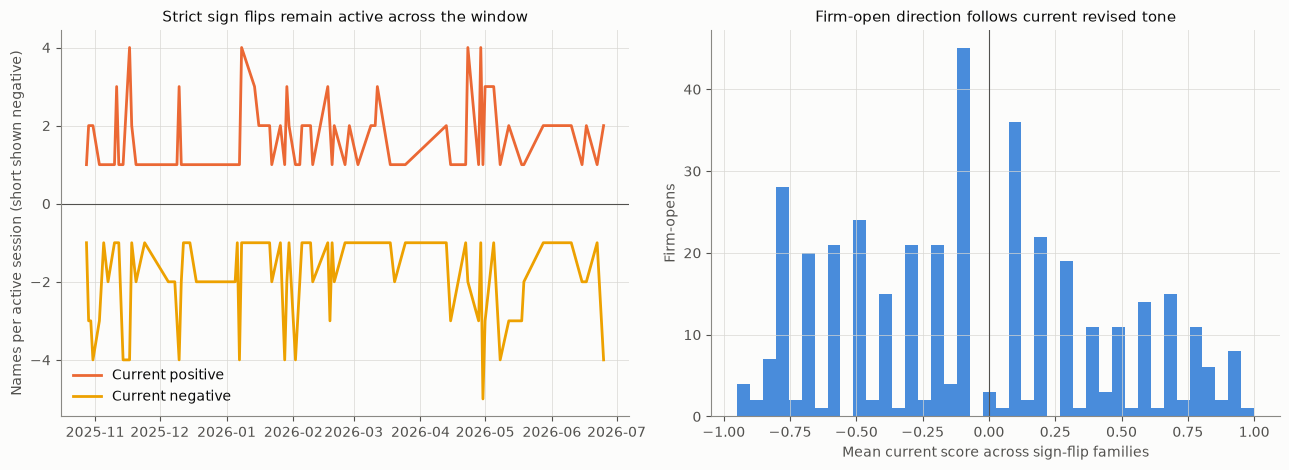

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
active_audit = flip_target_audit.loc[flip_target_audit["eligible"]]
axes[0].plot(
    active_audit["session_date"],
    active_audit["positive_names"],
    color=CATEGORICAL[1],
    label="Current positive",
)
axes[0].plot(
    active_audit["session_date"],
    -active_audit["negative_names"],
    color=CATEGORICAL[3],
    label="Current negative",
)
axes[0].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].set_ylabel("Names per active session (short shown negative)")
axes[0].set_title("Strict sign flips remain active across the window")
axes[0].legend(loc="best")
axes[1].hist(
    firm_open["mean_current_flip_score"],
    bins=40,
    color=CATEGORICAL[0],
    alpha=0.85,
)
axes[1].axvline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xlabel("Mean current score across sign-flip families")
axes[1].set_ylabel("Firm-opens")
axes[1].set_title("Firm-open direction follows current revised tone")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "sign_flip_breadth.png", dpi=170, bbox_inches="tight")
plt.show()

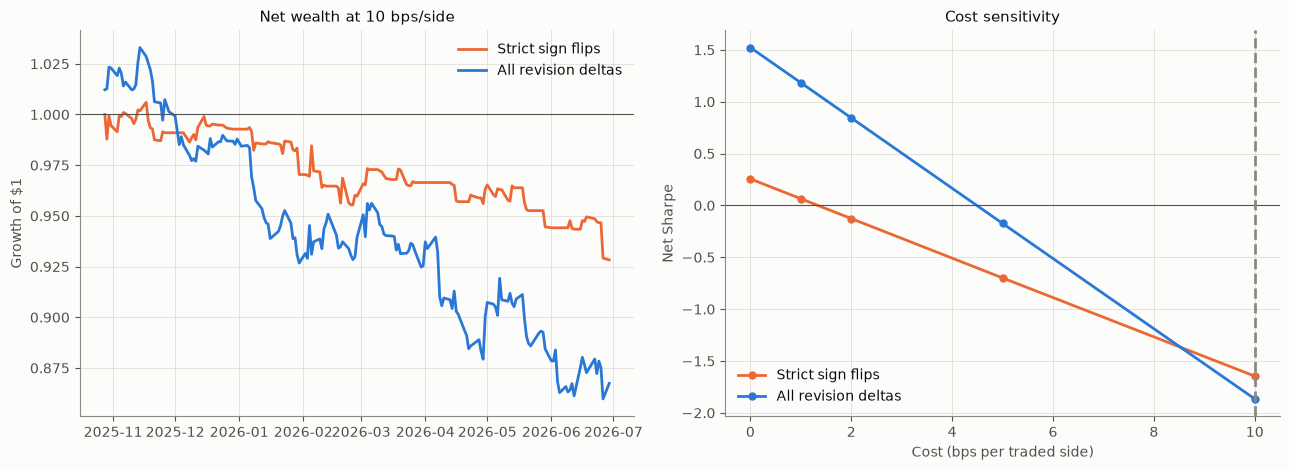

In [13]:
labels = {
    "strict_sign_flip": "Strict sign flips",
    "revision_delta": "All revision deltas",
}
colours = {
    "strict_sign_flip": CATEGORICAL[1],
    "revision_delta": CATEGORICAL[0],
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for arm, daily in daily_paths.items():
    axes[0].plot(
        daily["return_end_date"],
        (1.0 + daily["net_return"]).cumprod(),
        color=colours[arm],
        label=labels[arm],
    )
axes[0].axhline(1.0, color=INK["reference"], linewidth=0.8)
axes[0].set_ylabel("Growth of $1")
axes[0].set_title("Net wealth at 10 bps/side")
axes[0].legend(loc="best")
for arm in target_arms:
    line = cost_curve.loc[cost_curve["arm"].eq(arm)]
    axes[1].plot(
        line["cost_bps_per_side"],
        line["sharpe_net"],
        marker="o",
        color=colours[arm],
        label=labels[arm],
    )
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].axvline(COST_BPS, color=INK["muted"], linestyle="--")
axes[1].set_xlabel("Cost (bps per traded side)")
axes[1].set_ylabel("Net Sharpe")
axes[1].set_title("Cost sensitivity")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "equity_and_cost.png", dpi=170, bbox_inches="tight")
plt.show()

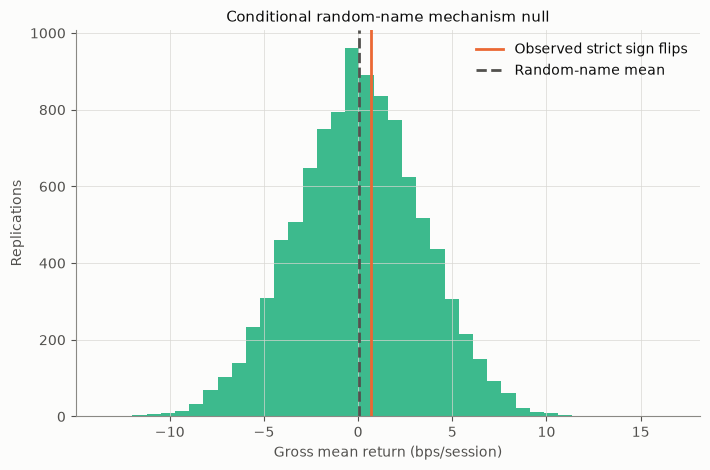

In [14]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.hist(random_means * 10_000, bins=40, color=CATEGORICAL[2], alpha=0.85)
ax.axvline(
    actual_gross_mean * 10_000,
    color=CATEGORICAL[1],
    linewidth=2.0,
    label="Observed strict sign flips",
)
ax.axvline(
    float(randomisation.loc[0, "null_mean"]) * 10_000,
    color=INK["reference"],
    linestyle="--",
    label="Random-name mean",
)
ax.set_xlabel("Gross mean return (bps/session)")
ax.set_ylabel("Replications")
ax.set_title("Conditional random-name mechanism null")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "conditional_random_names.png", dpi=170, bbox_inches="tight")
plt.show()

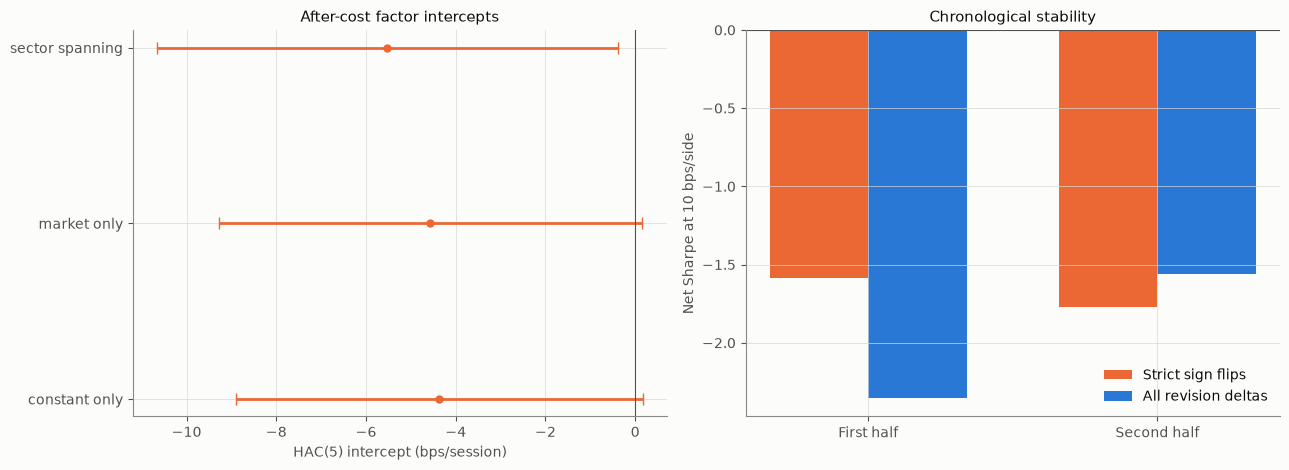

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
models = factor_models.set_index("model").loc[list(model_specs)]
y = np.arange(len(models))
axes[0].errorbar(
    models["alpha_bps_session"],
    y,
    xerr=np.vstack(
        [
            models["alpha_bps_session"] - models["alpha_ci_low_bps_session"],
            models["alpha_ci_high_bps_session"] - models["alpha_bps_session"],
        ]
    ),
    fmt="o",
    color=CATEGORICAL[1],
    capsize=4,
)
axes[0].axvline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].set_yticks(y, [name.replace("_", " ") for name in models.index])
axes[0].set_xlabel("HAC(5) intercept (bps/session)")
axes[0].set_title("After-cost factor intercepts")
half_plot = temporal.pivot(index="period", columns="arm", values="sharpe_net").reindex(
    ["first_half", "second_half"]
)
x = np.arange(len(half_plot))
width = 0.34
for offset, arm in enumerate(target_arms):
    axes[1].bar(
        x + (offset - 0.5) * width,
        half_plot[arm],
        width,
        color=colours[arm],
        label=labels[arm],
    )
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xticks(x, ["First half", "Second half"])
axes[1].set_ylabel("Net Sharpe at 10 bps/side")
axes[1].set_title("Chronological stability")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "factor_and_temporal.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate evidence and decision

In [16]:
transition_summary.to_csv(OUTPUT_DIR / "transition_summary.csv", index=False)
input_summary.to_csv(OUTPUT_DIR / "input_summary.csv", index=False)
firm_open.to_parquet(OUTPUT_DIR / "firm_open_sign_flips.parquet", index=False)
flip_target_audit.to_csv(OUTPUT_DIR / "sign_flip_target_audit.csv", index=False)
delta_target_audit.to_csv(OUTPUT_DIR / "delta_target_audit.csv", index=False)
coverage.to_csv(OUTPUT_DIR / "coverage.csv", index=False)
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
inference.to_csv(OUTPUT_DIR / "inference.csv", index=False)
randomisation.to_csv(OUTPUT_DIR / "conditional_random_names.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal.csv", index=False)
factor_models.to_csv(OUTPUT_DIR / "factor_models.csv", index=False)
company_loo.to_csv(OUTPUT_DIR / "leave_one_company_out.csv", index=False)
sector_loo.to_csv(OUTPUT_DIR / "leave_one_sector_out.csv", index=False)
attribution.to_csv(OUTPUT_DIR / "company_attribution.csv", index=False)
dependence.to_csv(OUTPUT_DIR / "dependence_summary.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
for arm, daily in daily_paths.items():
    daily.to_parquet(OUTPUT_DIR / f"{arm}_daily.parquet", index=False)

output_hashes = {
    name: sha256_file(OUTPUT_DIR / name)
    for name in (
        "firm_open_sign_flips.parquet",
        "sign_flip_target_audit.csv",
        "results.csv",
        "inference.csv",
        "conditional_random_names.csv",
        "gates.csv",
    )
}

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

status = (
    "RETROSPECTIVE_STRICT_SIGN_FLIP_ALL_GATES_PASS_NOT_VALIDATED"
    if retrospective_strategy_gate
    else "RETROSPECTIVE_STRICT_SIGN_FLIP_NO_GO"
)
manifest = {
    "status": status,
    "notebook": "49_lseg_gemma_story_revision_sign_flip.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "gemma_scores": str(GEMMA_PATH.relative_to(REPO_ROOT)),
        "gemma_scores_sha256": score_audit["output_sha256"],
        "merged_corpus": str(MERGED_HEADLINES.relative_to(REPO_ROOT)),
        "merged_corpus_sha256": family_audit["corpus_sha256"],
        "aggregate_session_grid": str(AGGREGATE_PANEL.relative_to(REPO_ROOT)),
        "aggregate_session_grid_sha256": sha256_file(AGGREGATE_PANEL),
        "notebook47_manifest": str(NOTEBOOK47_MANIFEST.relative_to(REPO_ROOT)),
        "notebook47_manifest_sha256": sha256_file(NOTEBOOK47_MANIFEST),
        "licensed_headline_text_emitted": False,
        "raw_story_ids_emitted": False,
        "returns_loaded_only_after_input_gate": True,
    },
    "return_free_input": json.loads(input_summary.to_json(orient="records"))[0],
    "specification": {
        "universe": "immutable original 33 LSEG companies",
        "signal": "strict first-to-current Gemma sign flip; mean current score within firm-open",
        "association": "company must be present in first and current family revisions",
        "deduplication": "latest transition per family/company/entry open",
        "information_buffer_minutes": 15,
        "long": "strictly positive mean current score among sign-flip families",
        "short": "strictly negative mean current score among sign-flip families",
        "strategy_comparator": "Notebook 47 broad revision-delta strategy reproduced exactly",
        "random_control": "same active dates, counts, gross and same-day revision-update universe",
        "single_name_cap": SINGLE_NAME_CAP,
        "gross_exposure": 1.0,
        "holding_intervals": 1,
        "cost_bps_per_traded_side": COST_BPS,
        "block_inference": f"{REPLICATIONS} five-session circular-block replications",
        "multiplicity": "two return comparisons; BH-FDR q=0.05",
        "factor_control": "HAC(5) market plus ten sector-minus-market returns",
        "final_liquidation": True,
    },
    "results": json.loads(results.to_json(orient="records")),
    "inference": json.loads(inference.to_json(orient="records")),
    "conditional_random_names": json.loads(
        randomisation.to_json(orient="records")
    )[0],
    "factor_models": json.loads(factor_models.to_json(orient="records")),
    "dependence": json.loads(dependence.to_json(orient="records"))[0],
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "output_hashes": output_hashes,
    "limitations": [
        "the 2025-2026 LSEG outcome window was opened repeatedly before this test",
        "Notebook 47 motivated strict sign flips as a bounded post-result semantic restriction",
        "vendor story-family syntax and revision behaviour may not transfer to other feeds",
        "headline-level Gemma accuracy on the licensed population lacks human validation",
        "the broad revision comparator uses more firms and active sessions than the strict subset",
        "sector factors are contemporaneous internal equal-weight benchmarks",
        "prices are split adjusted but not dividend adjusted",
        "no result can be promoted before Gate F1 or called deployable alpha",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_STRICT_SIGN_FLIP_NO_GO",
  "notebook": "49_lseg_gemma_story_revision_sign_flip.ipynb",
  "git_commit_at_execution": "6b6e8ea9db63dca27efcc412712964241ca3d5a9",
  "seed": 20260818,
  "input": {
    "gemma_scores": "Data/collections/lseg_us_sector_44_8m_headlines/derived/headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv",
    "gemma_scores_sha256": "afb2d9c3029c4fba4fce3600218233a02d14051788f87313fd49c9da681c6d2f",
    "merged_corpus": "Data/collections/lseg_us_sector_44_8m_headlines/derived/merged/headlines.jsonl",
    "merged_corpus_sha256": "7f48c46690f3293cbfe846ddecc701852daf3c35643f2747dcbc39f829927878",
    "aggregate_session_grid": "final_experiments/outputs/13_lseg_44_gemma_robustness/gemma4_26b_firm_open_aggregators.parquet",
    "aggregate_session_grid_sha256": "2fe436f1d75fce77c821cd6a05d4dbd4fa0473a0e7026400e2a90649003689a5",
    "notebook47_manifest": "final_experiments/outputs/47_lseg_gemma_story_revision_delta

## Decision

In [17]:
decision = f"""
**{status.replace('_', ' ')}.** The return-free gate passes with
**{int(input_summary.loc[0, 'strict_sign_flip_firm_opens']):,}** sign-flip
firm-opens across **{int(input_summary.loc[0, 'strict_sign_flip_symbols'])}**
companies and **{int(input_summary.loc[0, 'both_sign_active_sessions'])}/167**
both-sign active sessions.

At 10 bps/side, strict sign flips have gross/net Sharpe
**{flip_result['sharpe_gross']:.3f}/{flip_result['sharpe_net']:.3f}**, net return
**{flip_result['total_return_net']:.2%}**, drawdown
**{flip_result['max_drawdown']:.2%}**, and break-even
**{flip_result['breakeven_bps_per_side']:.2f} bps/side**. The reproduced broad
revision arm has net Sharpe **{revision_result['sharpe_net']:.3f}** and net
return **{revision_result['total_return_net']:.2%}**.

Strict sign flips minus cash are **{cash_test['mean_difference'] * 10_000:+.3f}
bps/session** with interval **[{cash_test['ci_low'] * 10_000:+.3f},
{cash_test['ci_high'] * 10_000:+.3f}]** and BH q=
**{cash_test['q_bh_two_test']:.4f}**. Strict sign flips minus broad revision
delta are **{delta_test['mean_difference'] * 10_000:+.3f} bps/session** with
interval **[{delta_test['ci_low'] * 10_000:+.3f},
{delta_test['ci_high'] * 10_000:+.3f}]** and BH q=
**{delta_test['q_bh_two_test']:.4f}**. The conditional random-name one-sided p
is **{randomisation.loc[0, 'p_one_sided_greater']:.4f}**. Half Sharpes are
**{half_sharpes['first_half']:.3f}/{half_sharpes['second_half']:.3f}**. The
sector-spanning HAC alpha is **{sector_factor['alpha_bps_session']:+.3f}
bps/session** with interval **[{sector_factor['alpha_ci_low_bps_session']:+.3f},
{sector_factor['alpha_ci_high_bps_session']:+.3f}]**.

Cash alpha gate: **{cash_alpha_gate}**. Incremental sign-flip gate:
**{incremental_sign_flip_gate}**. Random-name mechanism gate:
**{random_name_mechanism_gate}**. Strategy-quality gate:
**{strategy_quality_gate}**. Factor-alpha gate: **{factor_alpha_gate}**.
Dependence-quality gate: **{dependence_quality_gate}**. Full retrospective gate:
**{retrospective_strategy_gate}**.

This is one disclosed semantic restriction of Reuters tone revisions. It is not
independent validation and cannot justify deployment or further revision-policy
tuning on these 167 sessions.
"""
display(Markdown(decision))


**RETROSPECTIVE STRICT SIGN FLIP NO GO.** The return-free gate passes with
**390** sign-flip
firm-opens across **32**
companies and **74/167**
both-sign active sessions.

At 10 bps/side, strict sign flips have gross/net Sharpe
**0.256/-1.646**, net return
**-7.17%**, drawdown
**-7.73%**, and break-even
**1.34 bps/side**. The reproduced broad
revision arm has net Sharpe **-1.866** and net
return **-13.26%**.

Strict sign flips minus cash are **-4.366
bps/session** with interval **[-9.428,
+0.388]** and BH q=
**0.1612**. Strict sign flips minus broad revision
delta are **+3.902 bps/session** with
interval **[-5.289,
+13.007]** and BH q=
**0.4090**. The conditional random-name one-sided p
is **0.4227**. Half Sharpes are
**-1.585/-1.773**. The
sector-spanning HAC alpha is **-5.524
bps/session** with interval **[-10.658,
-0.390]**.

Cash alpha gate: **False**. Incremental sign-flip gate:
**False**. Random-name mechanism gate:
**False**. Strategy-quality gate:
**False**. Factor-alpha gate: **False**.
Dependence-quality gate: **False**. Full retrospective gate:
**False**.

This is one disclosed semantic restriction of Reuters tone revisions. It is not
independent validation and cannot justify deployment or further revision-policy
tuning on these 167 sessions.
